# Spatial Hotspot Maps (Kernel-Density Grids)

This notebook builds 150 m metric grids over the study neighborhoods (projected to EPSG:26971 so the cells are truly metric rather than Web-Mercator-distorted), counts gun homicides and ShotSpotter alerts per cell, and renders comparison hotspot panels (homicide pre-2017, ShotSpotter, homicide post-2017) over a contextily basemap.

*Note: rendering the basemap tiles requires network access. This is an exploratory spatial notebook; the canonical analysis and all published figures live in the `scripts/` directory.*

In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.geometry import Polygon
from shapely import wkt
import contextily as ctx

## Load the cleaned incident data and boundaries

Reads the cleaned six-neighborhood homicide and ShotSpotter subsets from `data/processed/`, plus the raw street network and community-area boundaries.

In [2]:
homicide_data = pd.read_csv("../data/processed/Homicide_six_hoods.csv")
shotspotter_data = pd.read_csv("../data/processed/Shotspotter_six_hoods.csv")
streets = pd.read_csv("../data/raw/transportation_20250415.csv")
chicago_shapefile = gpd.read_file("../data/raw/CommAreas_20250408.geojson")

## Project to a metric CRS

Points, streets, and boundaries are converted to GeoDataFrames and reprojected to EPSG:26971 (Illinois State Plane, meters) so that the fixed-size grid cells are genuinely 150 m on a side.

In [3]:
chicago_shapefile.rename(columns={
    "community area": "community"}, inplace=True)

chicago_shapefile.loc[:, "community"] = chicago_shapefile["community"].str.title()

homicide_data['geometry'] = gpd.points_from_xy(homicide_data['Longitude'], homicide_data['Latitude'])
shotspotter_data['geometry'] = gpd.points_from_xy(shotspotter_data['Longitude'], shotspotter_data['Latitude'])
homicide_gdf = gpd.GeoDataFrame(homicide_data, geometry='geometry', crs='EPSG:4326')
shotspotter_gdf = gpd.GeoDataFrame(shotspotter_data, geometry='geometry', crs='EPSG:4326')

streets['geometry'] = streets['the_geom'].apply(wkt.loads)
streets_gdf = gpd.GeoDataFrame(streets, geometry='geometry', crs='EPSG:4326')

chicago_shapefile = chicago_shapefile.to_crs('EPSG:26971')
homicide_gdf = homicide_gdf.to_crs('EPSG:26971')
shotspotter_gdf = shotspotter_gdf.to_crs('EPSG:26971')
streets_gdf = streets_gdf.to_crs('EPSG:26971')

## Build the grids and the comparison-panel function

`create_grid` tiles each neighborhood with 150 m cells, `assign_to_grid` counts the incidents falling in each cell, and `visualize_6x3_layout` draws a 3x3 panel (homicide pre-2017, ShotSpotter, homicide post-2017) per neighborhood with shared color scales and a contextily basemap.

In [4]:
def create_grid(neighborhood_geom, grid_size=150):
    minx, miny, maxx, maxy = neighborhood_geom.bounds
    x_coords = np.arange(minx, maxx, grid_size)
    y_coords = np.arange(miny, maxy, grid_size)
    grids = []
    for x in x_coords:
        for y in y_coords:
            grids.append(Polygon([(x, y), (x + grid_size, y), (x + grid_size, y + grid_size), (x, y + grid_size)]))
    return gpd.GeoDataFrame({'geometry': grids}, crs='EPSG:26971')

def assign_to_grid(incident_gdf, grid_gdf):
    joined = gpd.sjoin(incident_gdf, grid_gdf, how='left', predicate='intersects')
    grid_counts = joined.groupby('index_right').size()
    grid_gdf['count'] = grid_gdf.index.map(grid_counts)
    grid_gdf['count'] = grid_gdf['count'].fillna(0)
    return grid_gdf

def visualize_6x3_layout(homicide_gdf, shotspotter_gdf, streets_gdf, chicago_shapefile, selected_neighborhoods):
    fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(24, 28), constrained_layout=False)

    plt.subplots_adjust(
        wspace=0.25,
        hspace=0.25,
        left=0.04,
        right=0.75,
        top=0.95,
        bottom=0.25
    )

    pre_2017 = homicide_gdf[homicide_gdf['Date'] < '2017-01-13']
    post_2017 = homicide_gdf[homicide_gdf['Date'] >= '2017-01-13']
    
    buffer_distance = 400

    # Bug 5 fix: pre-compute global max for consistent colorbars
    global_max_pre = 0
    global_max_post = 0
    global_max_ss = 0
    for _nb in selected_neighborhoods:
        _ng = chicago_shapefile[chicago_shapefile['community'] == _nb].geometry.values[0]
        _g1 = assign_to_grid(pre_2017, create_grid(_ng, grid_size=150))
        _g2 = assign_to_grid(post_2017, create_grid(_ng, grid_size=150))
        _g3 = assign_to_grid(shotspotter_gdf, create_grid(_ng, grid_size=150))
        global_max_pre = max(global_max_pre, _g1['count'].max())
        global_max_post = max(global_max_post, _g2['count'].max())
        global_max_ss = max(global_max_ss, _g3['count'].max())

    for idx, neighborhood in enumerate(selected_neighborhoods):
        ax1, ax2, ax3 = axes[idx]

        neighborhood_geom = chicago_shapefile[chicago_shapefile['community'] == neighborhood].geometry.values[0]
        neighborhood_buffer = neighborhood_geom.buffer(buffer_distance)

        pre_grid_gdf = create_grid(neighborhood_geom, grid_size=150)
        post_grid_gdf = create_grid(neighborhood_geom, grid_size=150)
        shotspotter_grid_gdf = create_grid(neighborhood_geom, grid_size=150)

        pre_grid = assign_to_grid(pre_2017, pre_grid_gdf)
        post_grid = assign_to_grid(post_2017, post_grid_gdf)
        shotspotter_grid = assign_to_grid(shotspotter_gdf, shotspotter_grid_gdf)

        def plot_background(ax):

            streets_gdf.plot(ax=ax, color='dimgray', linewidth=0.7, alpha=0.7)
            ax.grid(visible=True, color='lightgrey', linestyle='--', linewidth=0.5, alpha=0.5)
            ctx.add_basemap(ax, crs='EPSG:26971', source=ctx.providers.CartoDB.Positron, alpha=0.5)
            ax.set_xlim(neighborhood_buffer.bounds[0], neighborhood_buffer.bounds[2])
            ax.set_ylim(neighborhood_buffer.bounds[1], neighborhood_buffer.bounds[3])
            ax.axis('on')

        plot_background(ax1)
        pre_grid.plot(ax=ax1, column='count', cmap='OrRd', legend=False, alpha=1, vmin=0, vmax=global_max_pre)
        gpd.GeoDataFrame(geometry=[neighborhood_geom], crs='EPSG:26971').boundary.plot(ax=ax1, color='black', linewidth=1.5)
        ax1.set_title(f"{neighborhood} - Homicide Pre-2017", fontsize=18, fontweight='bold')

        plot_background(ax2)
        shotspotter_grid.plot(ax=ax2, column='count', cmap='Blues', legend=False, alpha=1, vmin=0, vmax=global_max_ss)
        gpd.GeoDataFrame(geometry=[neighborhood_geom], crs='EPSG:26971').boundary.plot(ax=ax2, color='black', linewidth=1.5)
        ax2.set_title(f"{neighborhood} - ShotSpotter", fontsize=18, fontweight='bold')

        plot_background(ax3)
        post_grid.plot(ax=ax3, column='count', cmap='OrRd', legend=False, alpha=1, vmin=0, vmax=global_max_post)
        gpd.GeoDataFrame(geometry=[neighborhood_geom], crs='EPSG:26971').boundary.plot(ax=ax3, color='black', linewidth=1.5)
        ax3.set_title(f"{neighborhood} - Homicide Post-2017", fontsize=18, fontweight='bold')

    sm_homicide = plt.cm.ScalarMappable(cmap='OrRd', norm=plt.Normalize(vmin=0, vmax=global_max_pre))
    sm_shotspot = plt.cm.ScalarMappable(cmap='Blues', norm=plt.Normalize(vmin=0, vmax=global_max_ss))

    cbar_homicide_pre = fig.colorbar(sm_homicide, ax=axes[:, 0], orientation='vertical', fraction=0.02, pad=0.02)
    cbar_homicide_pre.set_label('Homicide Count Pre-2017', fontsize=16, weight='bold')
    cbar_homicide_pre.ax.tick_params(labelsize=14)

    cbar_shotspot = fig.colorbar(sm_shotspot, ax=axes[:, 1], orientation='vertical', fraction=0.02, pad=0.02)
    cbar_shotspot.set_label('ShotSpotter Count', fontsize=16, weight='bold')
    cbar_shotspot.ax.tick_params(labelsize=14)

    sm_homicide_post = plt.cm.ScalarMappable(cmap='OrRd', norm=plt.Normalize(vmin=0, vmax=global_max_post))
    cbar_homicide_post = fig.colorbar(sm_homicide_post, ax=axes[:, 2], orientation='vertical', fraction=0.02, pad=0.02)
    cbar_homicide_post.set_label('Homicide Count Post-2017', fontsize=16, weight='bold')
    cbar_homicide_post.ax.tick_params(labelsize=14)

    plt.suptitle("Homicide and ShotSpotter Analysis by Chicago Neighborhood ", fontsize=20, fontweight='bold')
    plt.show()
    return fig


## West Side hotspot panel

Renders the comparison panels for the three West Side study neighborhoods (Austin, Humboldt Park, North Lawndale).

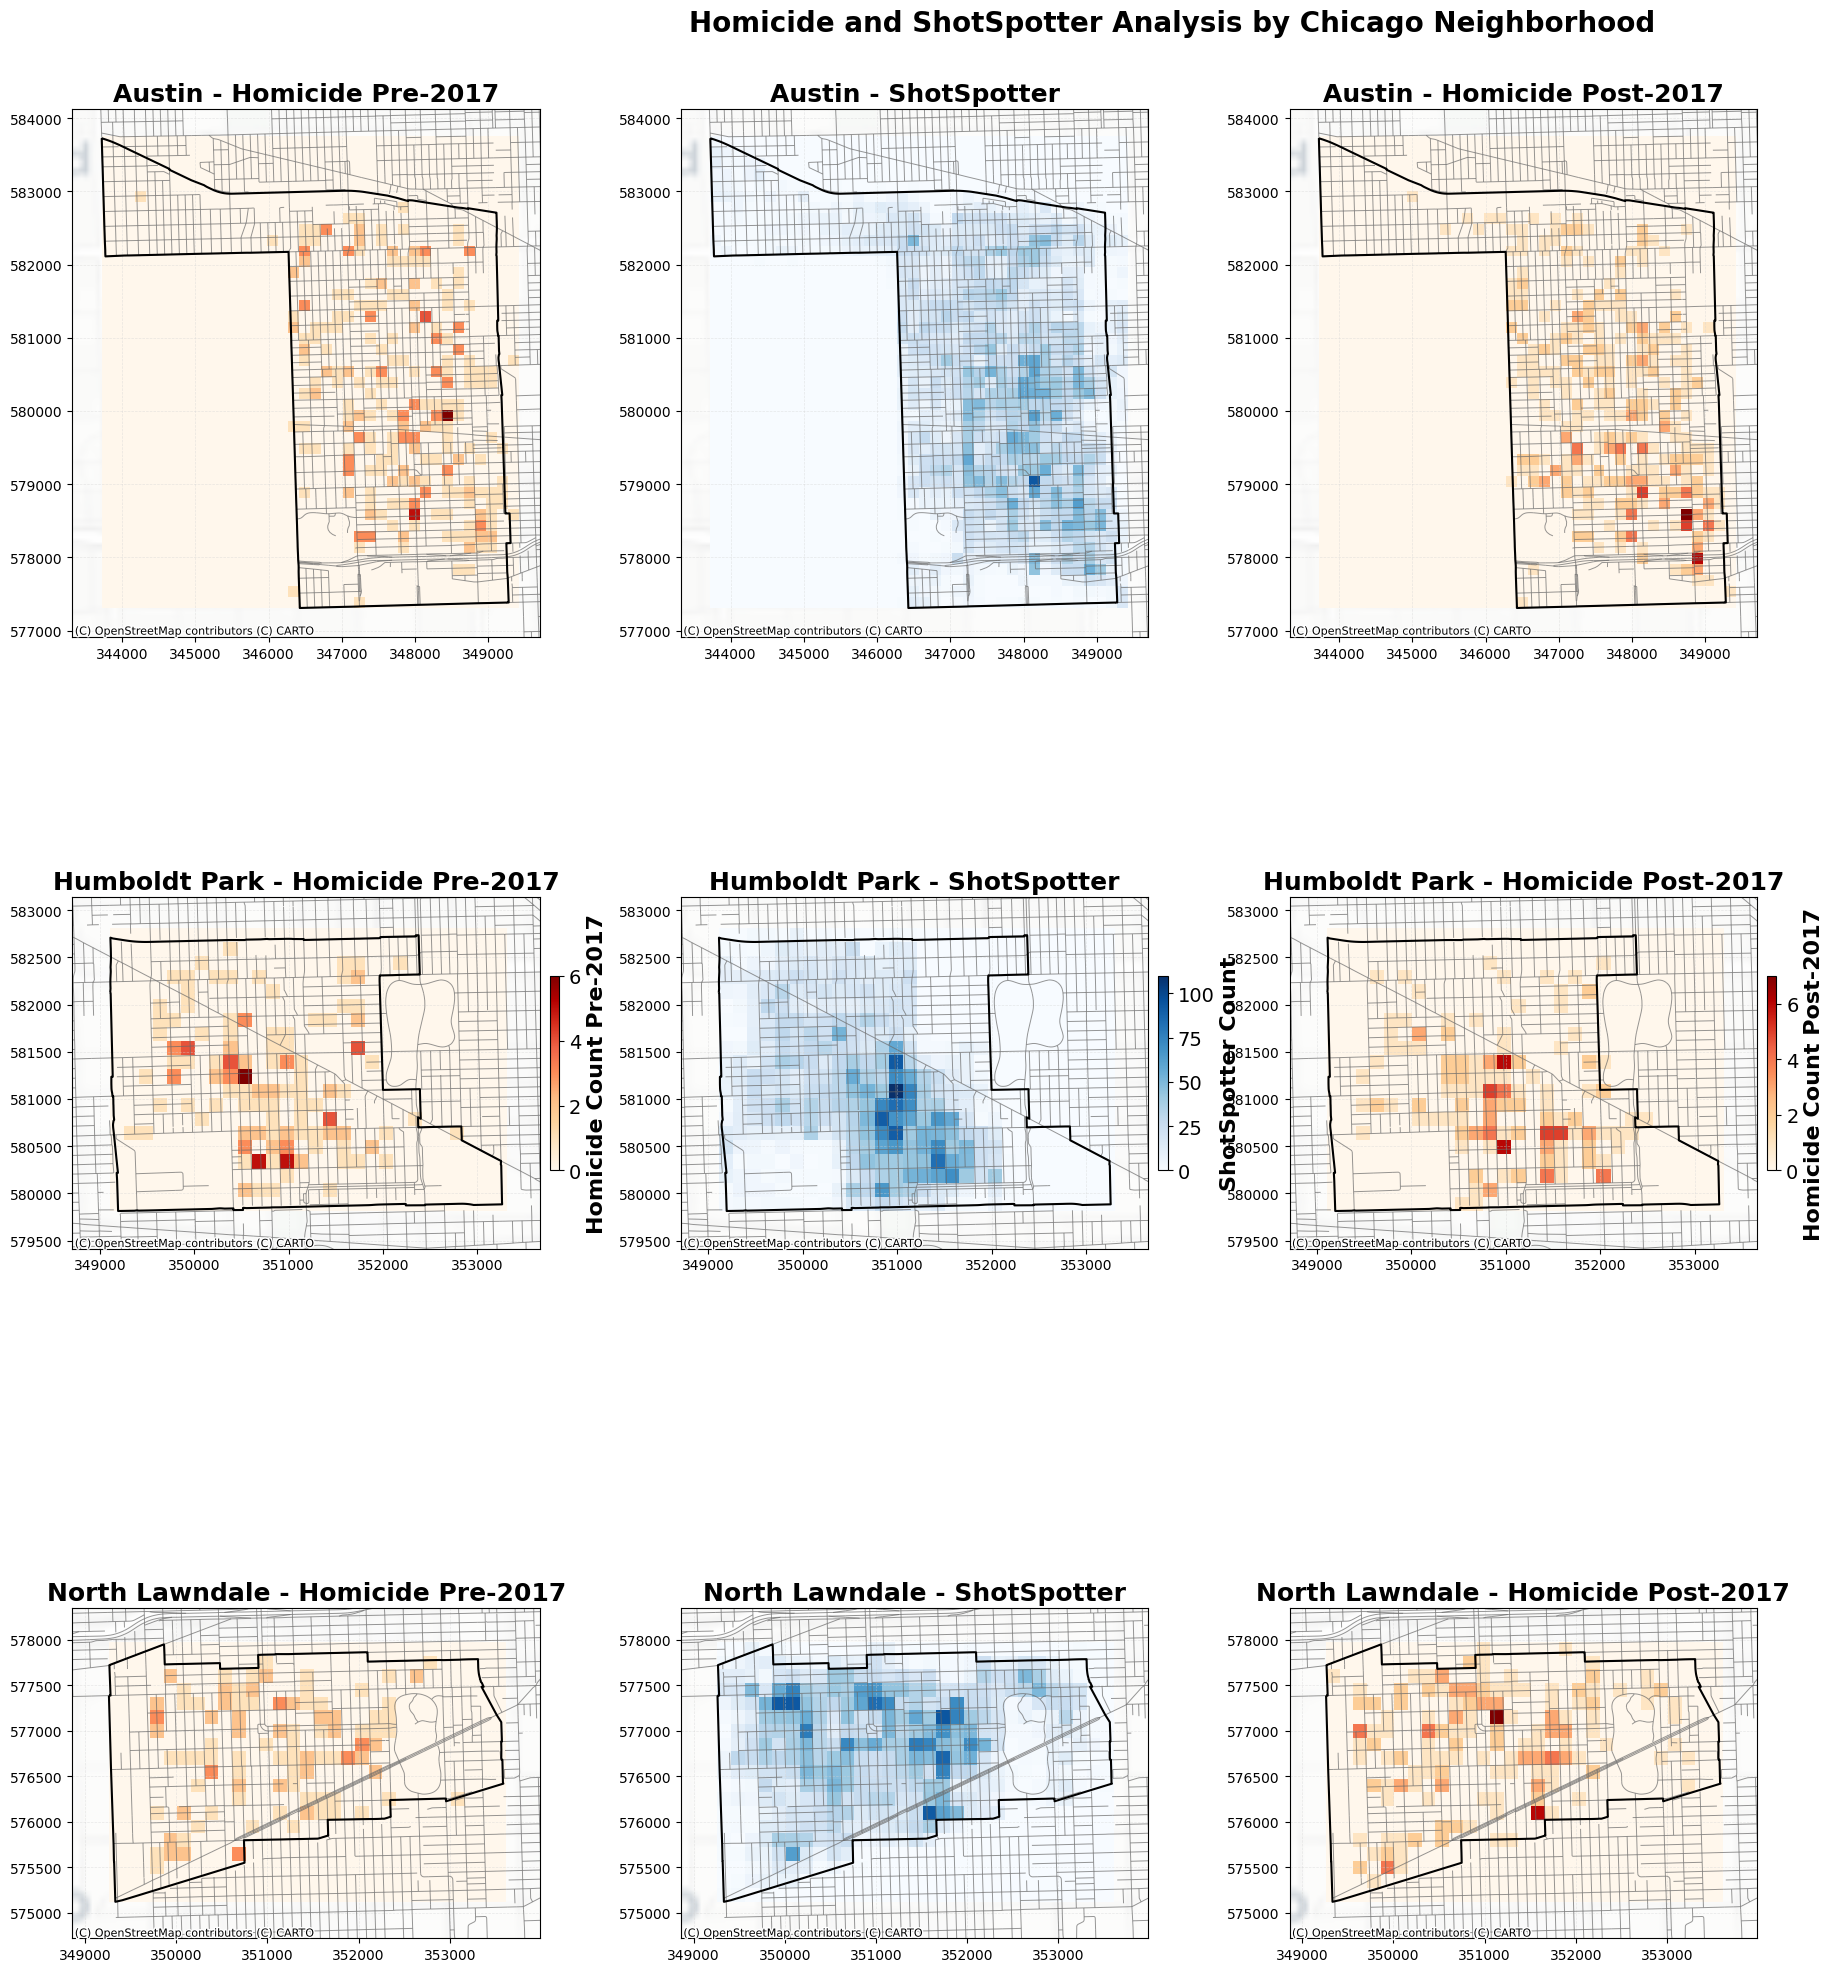

In [5]:
selected_neighborhoods = ['Austin', 'Humboldt Park', 'North Lawndale']
fig = visualize_6x3_layout(homicide_gdf, shotspotter_gdf, streets_gdf, chicago_shapefile, selected_neighborhoods)

## South Side hotspot panel

Renders the comparison panels for the three South Side study neighborhoods (Englewood, West Englewood, South Shore).

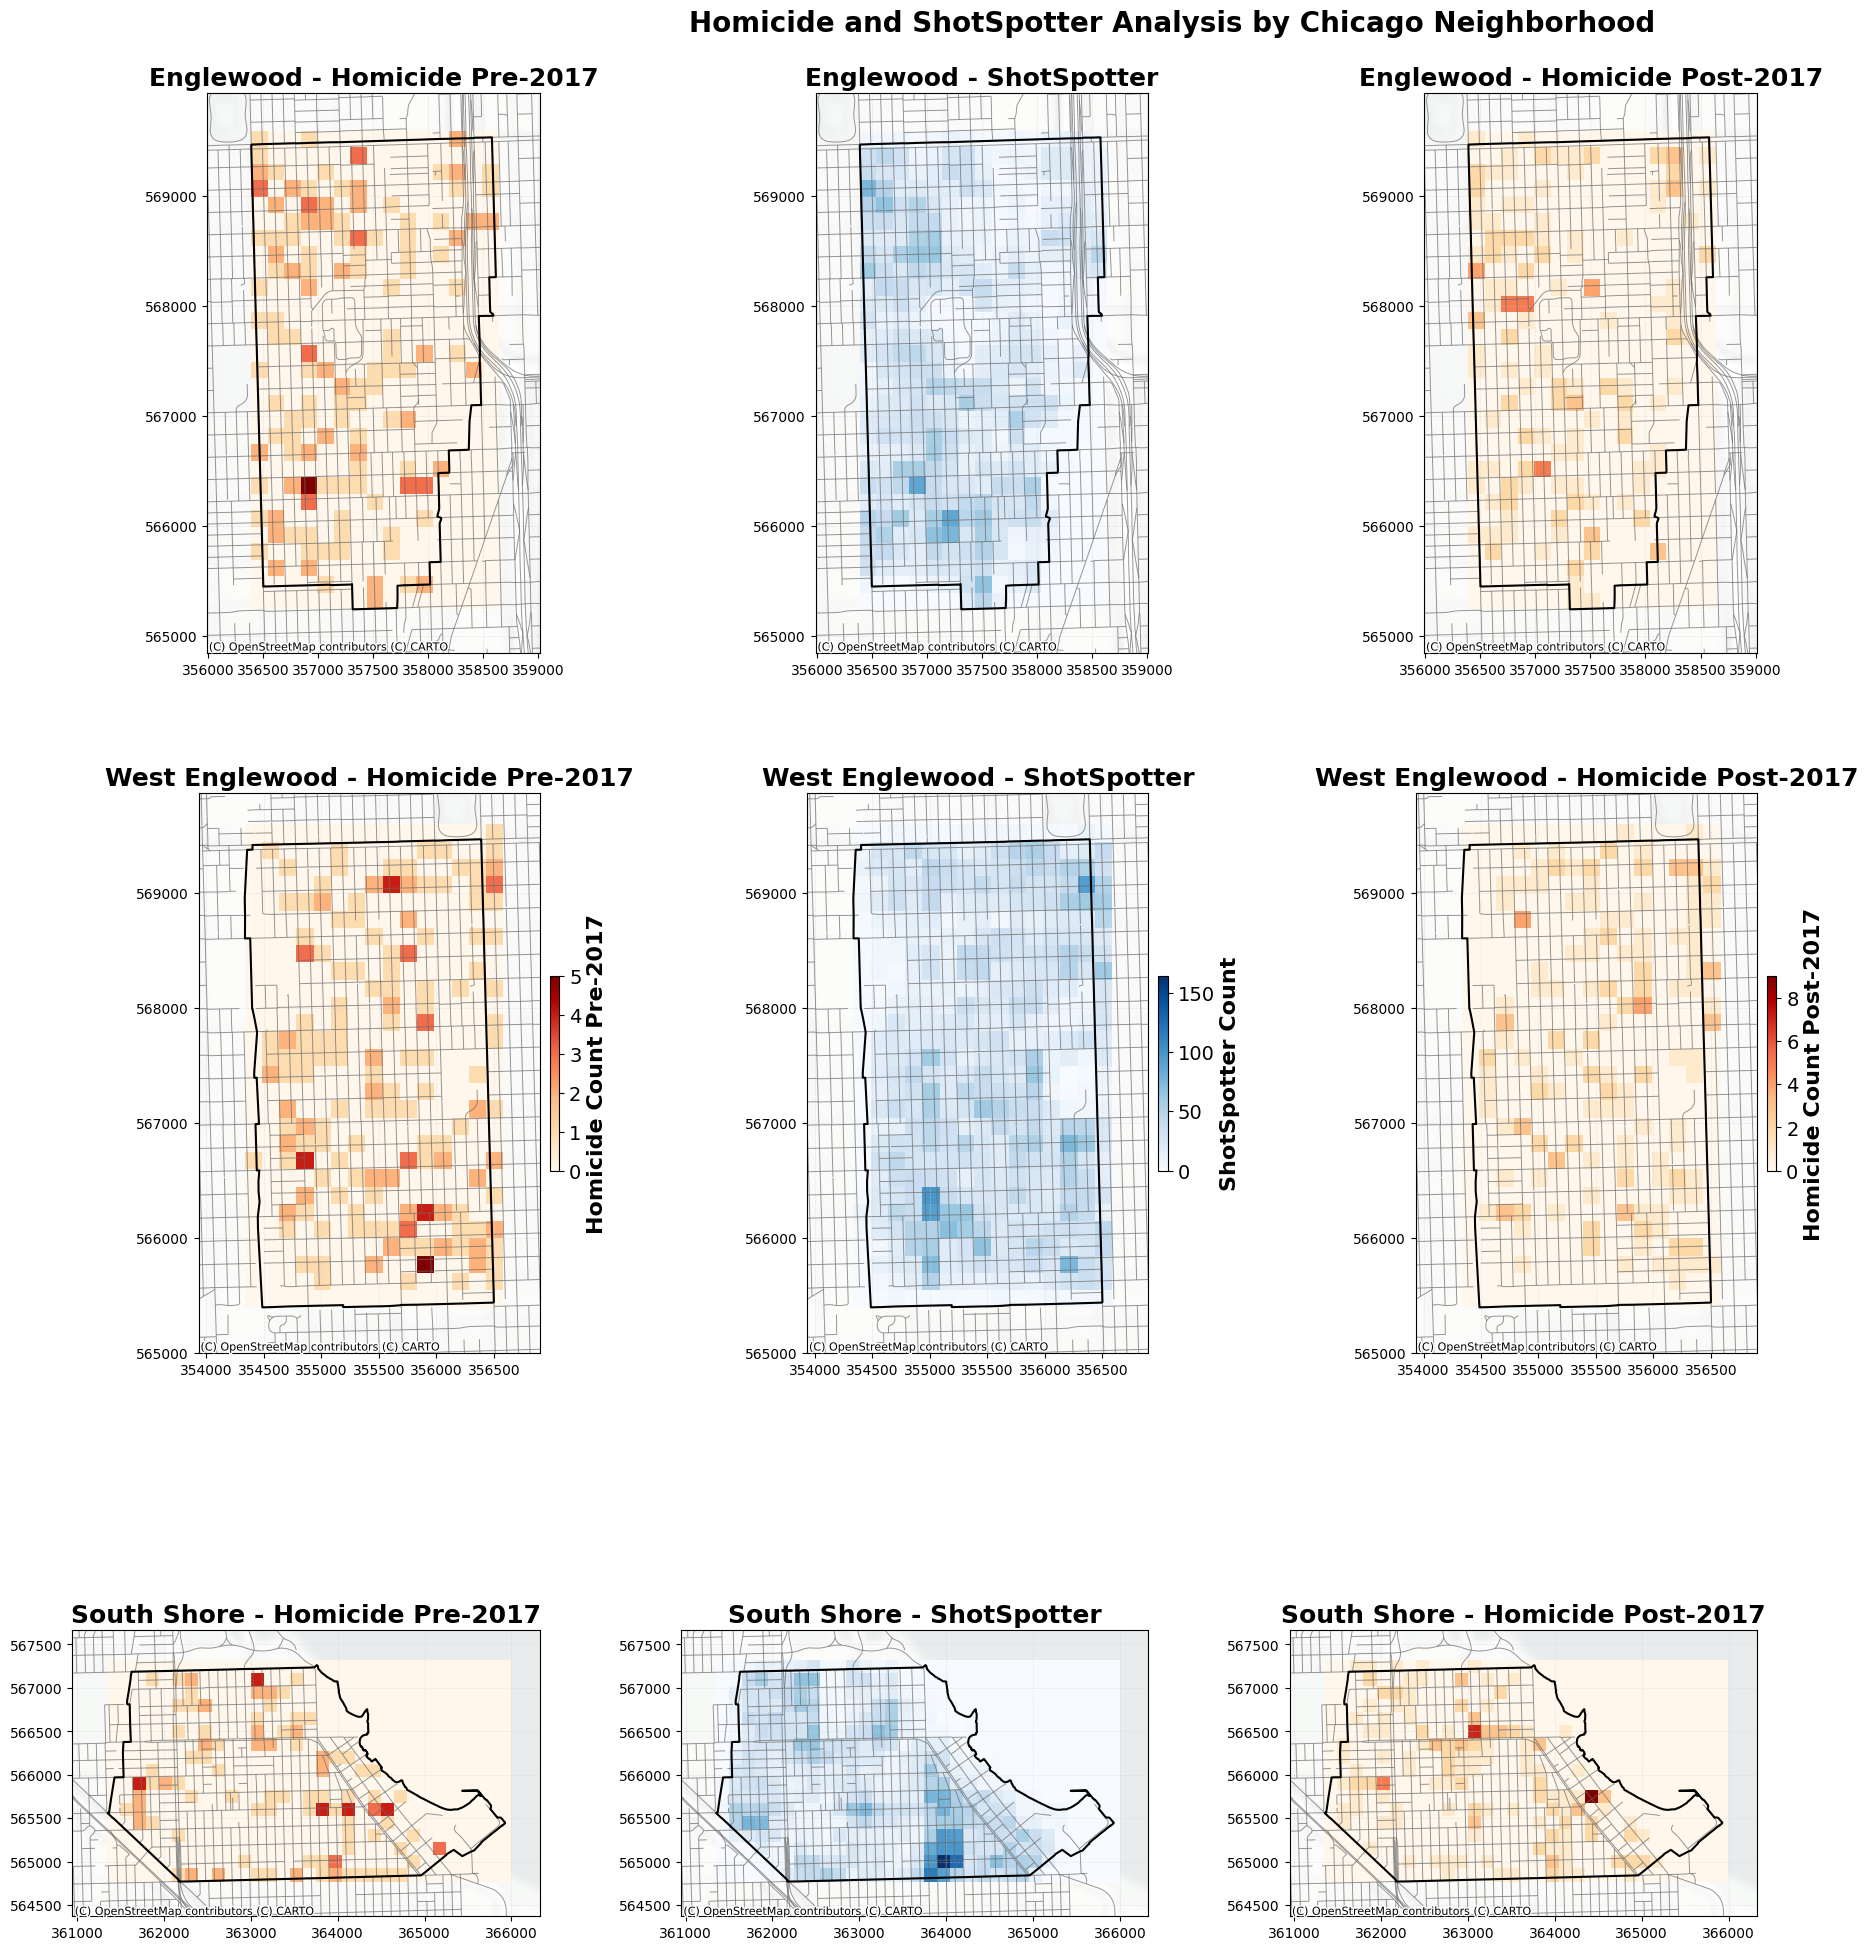

In [6]:
selected_neighborhoods = ['Englewood', 'West Englewood', 'South Shore']
fig = visualize_6x3_layout(homicide_gdf, shotspotter_gdf, streets_gdf, chicago_shapefile, selected_neighborhoods)